Классификация уровней ожирения


**Данные:** [Obesity Levels](https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels). В исходном сохранённом запуске: 2 111 объектов, 16 признаков и 7 классов. Датасет входит в список PDF. Признаки включают рост, вес и характеристики привычек; это учебная классификация, не медицинская рекомендация.


## Гипотезы и критерии проверки

1. Деревья будут лучше решать задачу многоклассовой классификации
2. Так как данных не очень много, а классов много, деревья будут сильно начинать переобучатья при увеличении глубины (от 5)
3. Weight может сильно коррелировать с другими признакакми такими как FAF, SMOKE, SCC, NCP, FCVC, FAVC.
4. Комбинация Height и Weight должны вносить основной вклад в предсказания таргета
5. Так как классы упорядочены модель: Линейная регрессия -> число -> пороги -> предсказание; должна работать лучше чем просто многоклассова классификация


## Загрузка и первичный анализ

Подключаем библиотеки и загружаем CSV. Исходная загрузка Kaggle сохранена.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [30]:
# Импорты, отсутствовавшие перед первым использованием в исходном файле.
from IPython.display import display, Markdown
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

In [31]:
from pathlib import Path

data_path = Path("ObesityDataSet_raw_and_data_sinthetic.csv")
df = pd.read_csv(data_path)
print(df.shape)
print(df.head())

Path to dataset files: /Users/denis/.cache/kagglehub/datasets/fatemehmehrparvar/obesity-levels/versions/1
(2111, 17)
    Age  Gender  Height  Weight        CALC FAVC  FCVC  NCP  SCC SMOKE  CH2O  \
0  21.0  Female    1.62    64.0          no   no   2.0  3.0   no    no   2.0   
1  21.0  Female    1.52    56.0   Sometimes   no   3.0  3.0  yes   yes   3.0   
2  23.0    Male    1.80    77.0  Frequently   no   2.0  3.0   no    no   2.0   
3  27.0    Male    1.80    87.0  Frequently   no   3.0  3.0   no    no   2.0   
4  22.0    Male    1.78    89.8   Sometimes   no   2.0  1.0   no    no   2.0   

  family_history_with_overweight  FAF  TUE       CAEC                 MTRANS  \
0                            yes  0.0  1.0  Sometimes  Public_Transportation   
1                            yes  3.0  0.0  Sometimes  Public_Transportation   
2                            yes  2.0  1.0  Sometimes  Public_Transportation   
3                             no  2.0  0.0  Sometimes                Walking   
4 

### Размер, типы и пропуски

In [32]:
df.describe(include='all').round(2)

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.00,2111,2111.00,2111.00,2111,2111,2111.00,2111.00,2111,2111,2111.00,2111,2111.00,2111.00,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.31,NaN,1.70,86.59,NaN,NaN,2.42,2.69,NaN,NaN,2.01,NaN,1.01,0.66,NaN,NaN,NaN
std,6.35,NaN,0.09,26.19,NaN,NaN,0.53,0.78,NaN,NaN,0.61,NaN,0.85,0.61,NaN,NaN,NaN
min,14.00,NaN,1.45,39.00,NaN,NaN,1.00,1.00,NaN,NaN,1.00,NaN,0.00,0.00,NaN,NaN,NaN
25%,19.95,NaN,1.63,65.47,NaN,NaN,2.00,2.66,NaN,NaN,1.58,NaN,0.12,0.00,NaN,NaN,NaN
50%,22.78,NaN,1.70,83.00,NaN,NaN,2.39,3.00,NaN,NaN,2.00,NaN,1.00,0.63,NaN,NaN,NaN
75%,26.00,NaN,1.77,107.43,NaN,NaN,3.00,3.00,NaN,NaN,2.48,NaN,1.67,1.00,NaN,NaN,NaN


In [33]:
df.isnull().sum()

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [34]:
print('Полных дубликатов:', df.duplicated().sum())
print('Пропусков всего:', int(df.isna().sum().sum()))

Полных дубликатов: 24
Пропусков всего: 0


В исходном файле все 17 столбцов имели 2 111 непустых значений. 

### Распределение классов (целевая переменная $Y$)

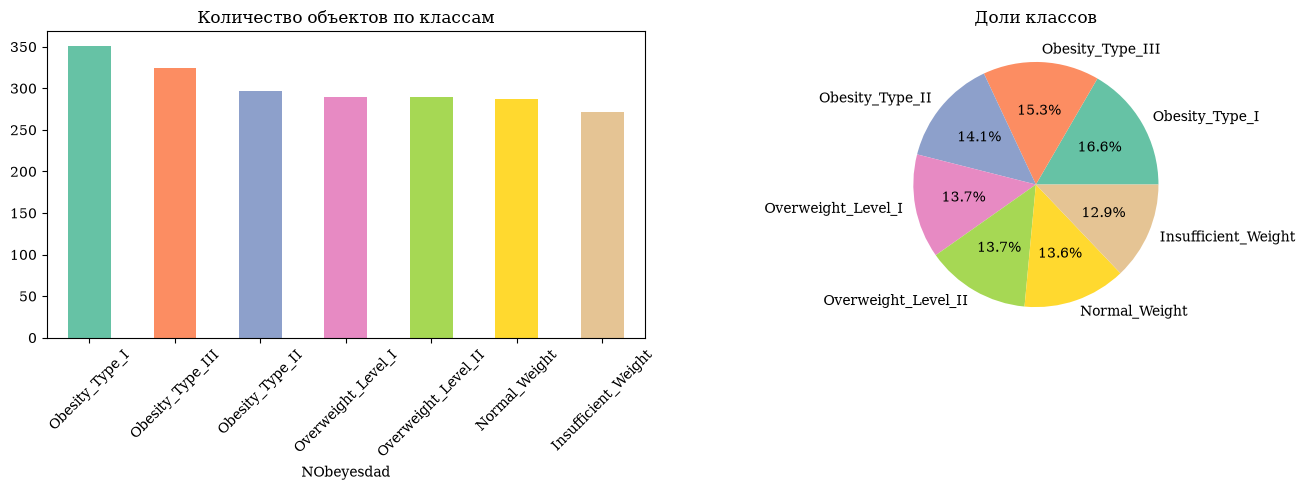

In [35]:
target_col = 'NObeyesdad'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

### Распределения признаков $x_1, x_2, \ldots, x_d$

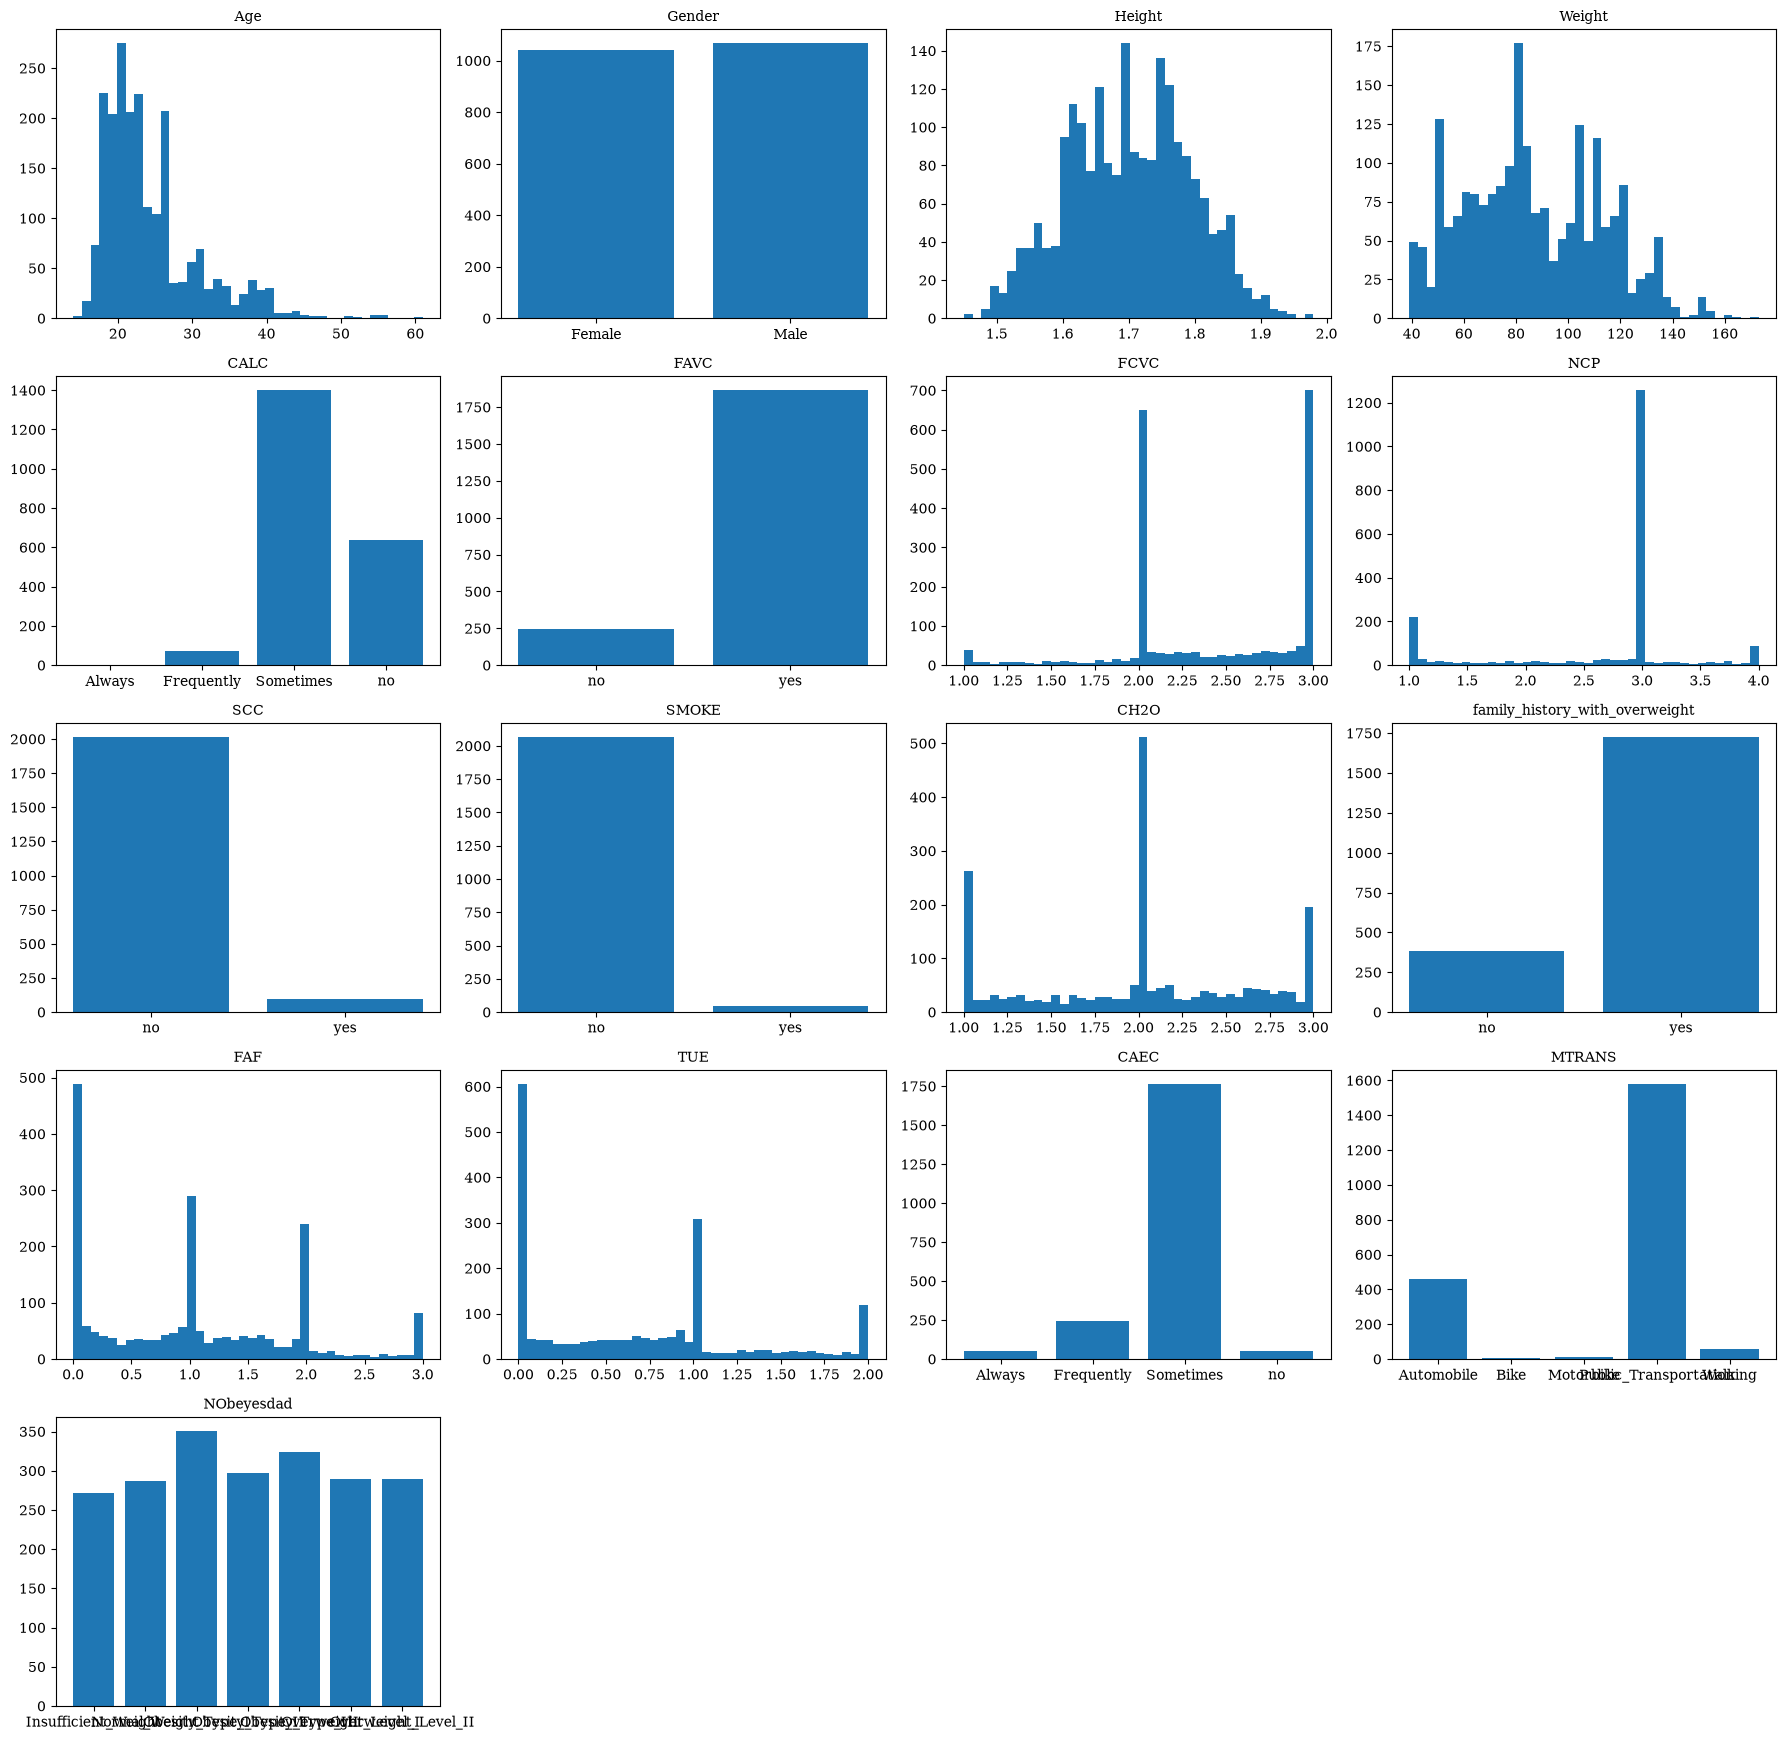

In [36]:
cols = df.columns.tolist()

n_plot_cols = 4
n_rows = (len(cols) + n_plot_cols - 1) // n_plot_cols

fig, axes = plt.subplots(
    n_rows,
    n_plot_cols,
    figsize=(18, n_rows * 3.5)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):
    n_unique = df[col].nunique()

    if pd.api.types.is_numeric_dtype(df[col]) and n_unique > 10:
        ax.hist(
            df[col].dropna(),
            bins=40
        )
    else:
        counts = df[col].value_counts(dropna=False).sort_index()

        ax.bar(
            counts.index.astype(str),
            counts.values
        )


    ax.set_title(col, fontsize=10)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Корреляции

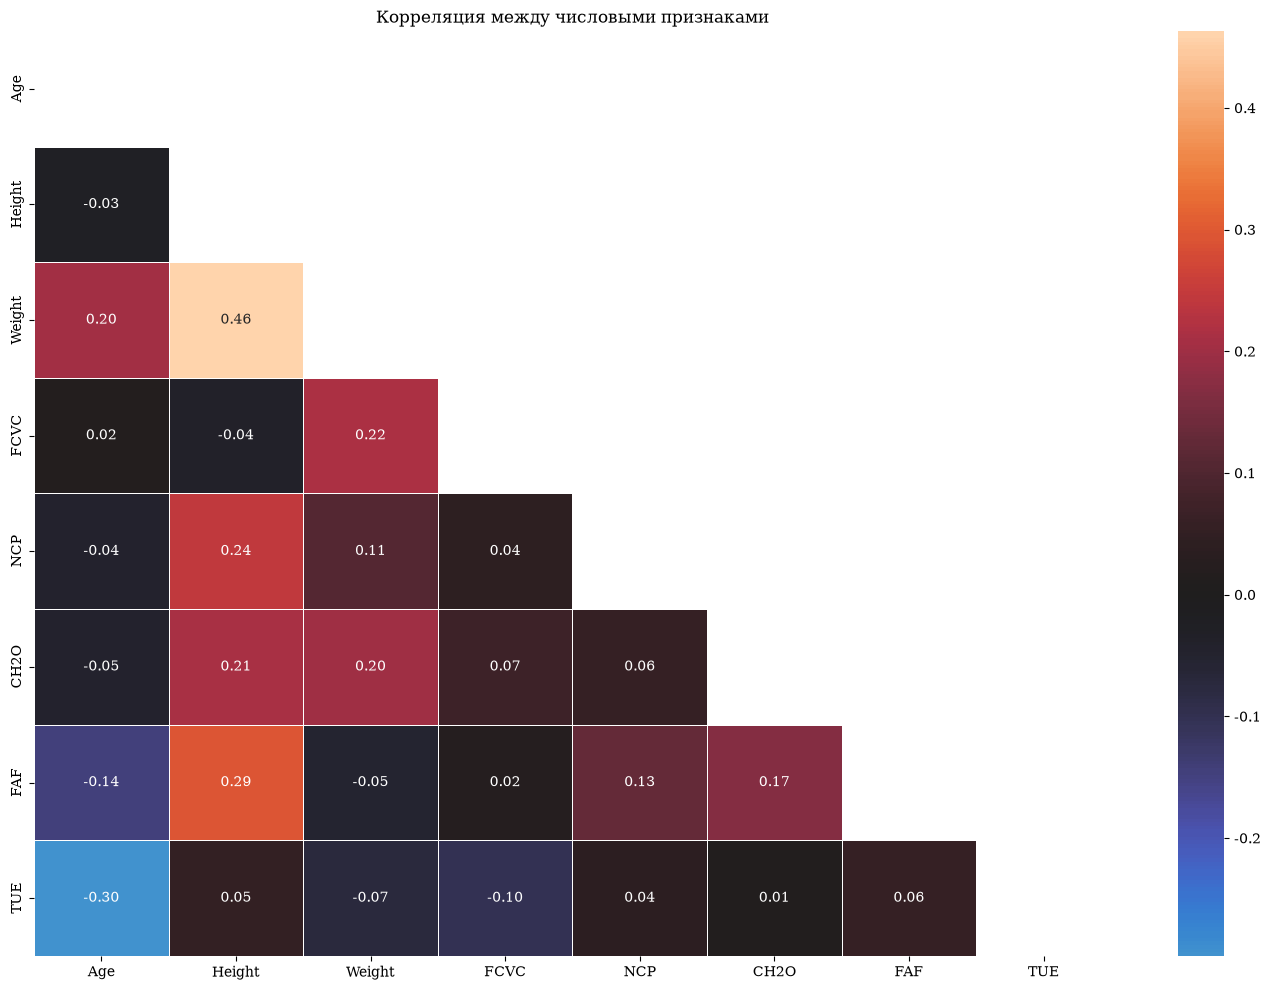

In [37]:
numeric_cols = df.select_dtypes(include='number').columns

corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    center=0,
    linewidths=0.5
)

plt.title('Корреляция между числовыми признаками')
plt.tight_layout()
plt.show()

### Совместные распределения

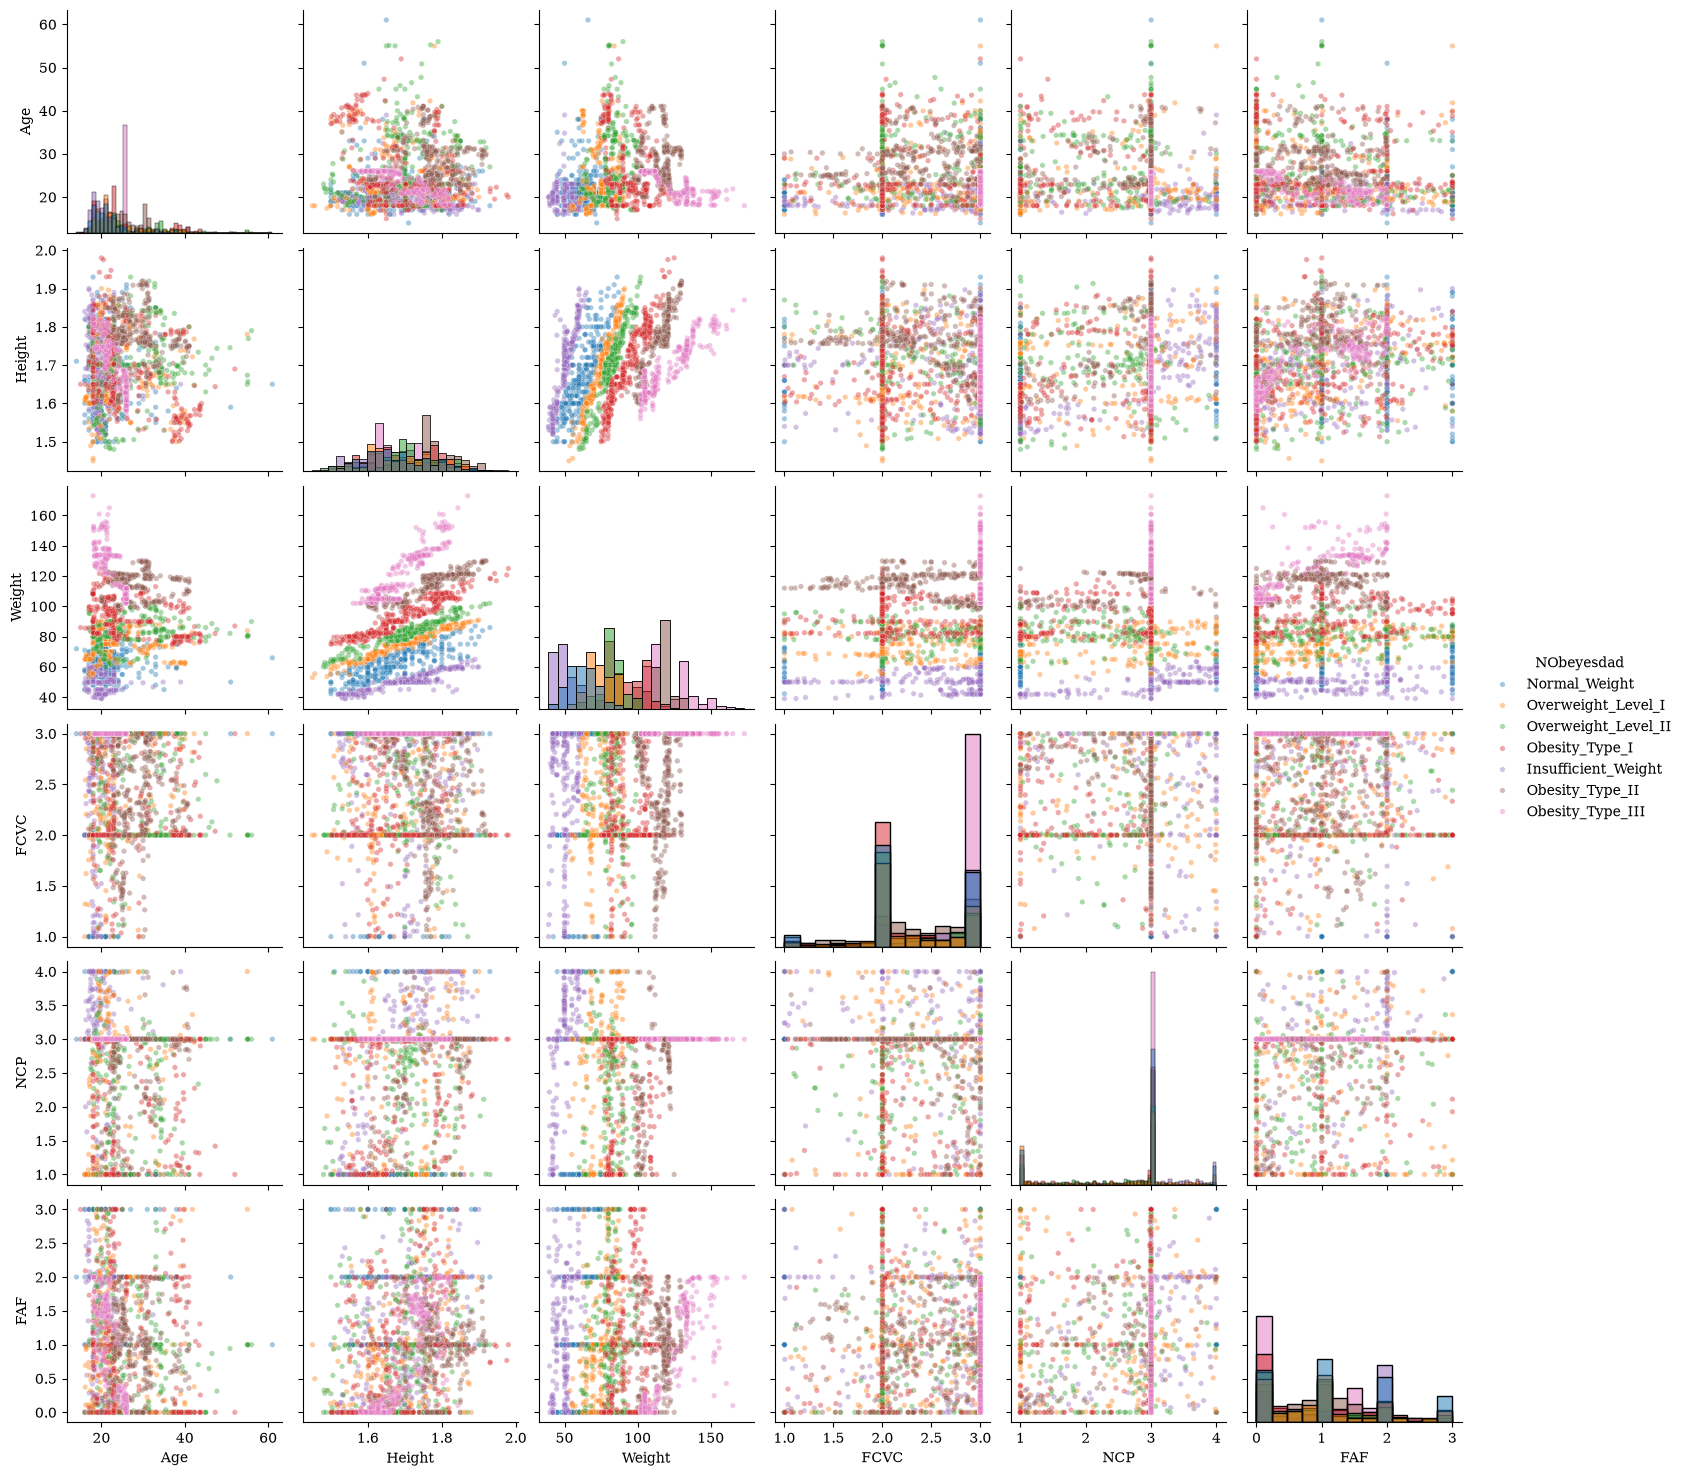

In [38]:
target_col = 'NObeyesdad'

features = [
    'Age',
    'Height',
    'Weight',
    'FCVC',
    'NCP',
    'FAF'
]

sns.pairplot(
    df[features + [target_col]],
    hue=target_col,
    plot_kws={
        'alpha': 0.4,
        's': 15
    },
    diag_kind='hist'
)

plt.show()

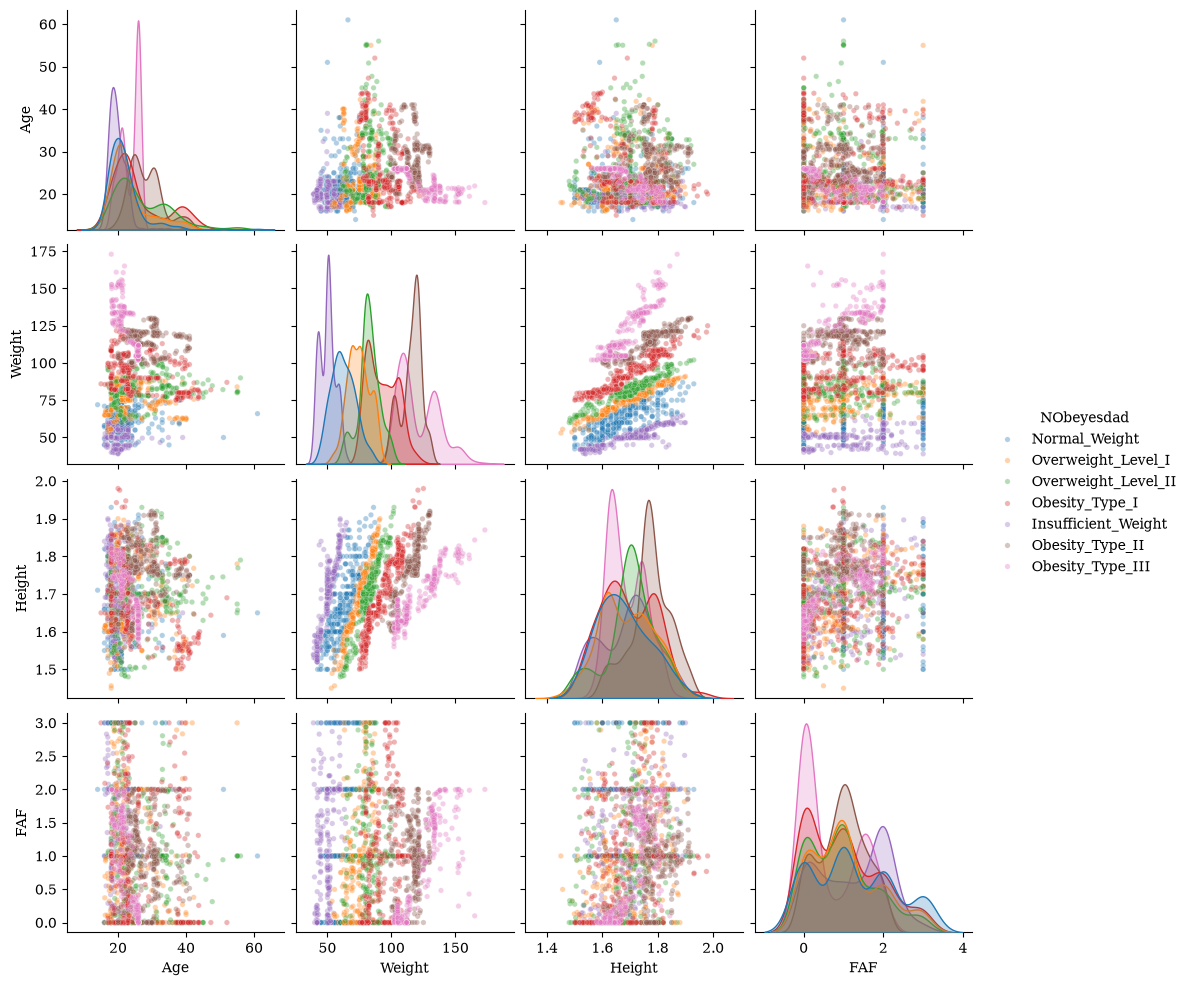

In [39]:
# df['BMI'] = df['Weight'] / df['Height'] ** 2
features = [
    'Age',
    'Weight',
    'Height',
    # 'BMI',
    'FAF'
]

sns.pairplot(
    df[features + ['NObeyesdad']],
    hue='NObeyesdad',
    plot_kws={
        'alpha': 0.35,
        's': 15
    }
)

plt.show()

## Подготовка данных

Подготовим данные с учётом упорядоченности классов

### Протокол и ограничения

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

class_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

class_to_num = {
    cls: i
    for i, cls in enumerate(class_order)
}

n_classes = len(class_order)


X_all = df.copy()

X_reg = X_all.drop(columns=['NObeyesdad'])
y_reg = X_all['NObeyesdad'].map(class_to_num).values

X_train_val_reg, X_test_reg, y_train_val_reg, y_test_reg =  train_test_split(X_reg, y_reg, test_size=0.2, random_state=52, stratify=y_reg)
X_train_reg, X_val_reg, y_train_reg, y_val_reg =  train_test_split(X_train_val_reg, y_train_val_reg, test_size=0.2, random_state=52, stratify=y_train_val_reg)

numeric_cols = X_reg.select_dtypes(include='number').columns
categorical_cols = X_reg.select_dtypes(exclude='number').columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train_reg_sc = preprocessor.fit_transform(X_train_reg)
X_val_reg_sc = preprocessor.transform(X_val_reg)
X_test_reg_sc = preprocessor.transform(X_test_reg)

preprocessor_reg = preprocessor


### Общие выборки для классификации и регрессии

Отдельный LabelEncoder больше не нужен: единая кодировка исключает неверные подписи матриц ошибок, а общие объекты делают сравнение порядковой регрессии и классификации корректнее.

In [41]:
X_cls = X_reg.copy()
y_cls = y_reg.copy()
X_train, X_val, X_test = X_train_reg, X_val_reg, X_test_reg
y_train_cls, y_val_cls, y_test_cls = y_train_reg, y_val_reg, y_test_reg
X_train_sc, X_val_sc, X_test_sc = X_train_reg_sc, X_val_reg_sc, X_test_reg_sc
preprocessor_cls = preprocessor_reg
preprocessor = preprocessor_cls


In [42]:
print('Train / validation / test:', len(X_train), len(X_val), len(X_test))
print('Порядок классов:', dict(enumerate(class_order)))
assert not pd.isna(y_reg).any(), 'Есть неизвестные названия классов'

Train / validation / test: 1350 338 423
Порядок классов: {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Overweight_Level_I', 3: 'Overweight_Level_II', 4: 'Obesity_Type_I', 5: 'Obesity_Type_II', 6: 'Obesity_Type_III'}


## Регрессия по порядковым меткам

### Непрерывное предсказание и фиксированные пороги

OLS, Ridge, Lasso и ElasticNet предсказывают число. `np.digitize` переводит его в класс через 0.5, 1.5, …, 5.5. Сами эти пороги не обучаются.

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Границы между семью классами
thresholds = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5])


def regression_to_class(y_pred_continuous, thresholds=thresholds):
    return np.digitize(y_pred_continuous, bins=thresholds)

In [44]:
from sklearn.base import clone


models_reg = {
    'OLS': LinearRegression(),

    'Ridge (alpha=0.5)': Ridge(alpha=0.5),
    'Ridge (alpha=10)': Ridge(alpha=10),

    'Lasso (alpha=0.5)': Lasso(alpha=0.5),
    'Lasso (alpha=100)': Lasso(alpha=100),
    'ElasticNet': ElasticNet(
        alpha=1,
        l1_ratio=0.05,
        max_iter=1_000
    )
}

results_reg = []
trained_models = {}


for name, base_model in models_reg.items():

    model = clone(base_model)

    # Обучение только на train
    model.fit(X_train_reg_sc, y_train_reg)

    # Сохраняем обученную модель
    trained_models[name] = model

    # Проверяем фиксированные пороги на validation
    y_val_continuous = model.predict(X_val_reg_sc)

    y_val_class = np.digitize(
        y_val_continuous,
        bins=np.arange(n_classes - 1) + 0.5
    )

    results_reg.append({
        'Model': name,
        'Validation RMSE': np.sqrt(
            mean_squared_error(y_val_reg, y_val_continuous)),
        'Validation MAE': mean_absolute_error(y_val_reg,y_val_continuous),
        'Validation R²': r2_score(y_val_reg, y_val_continuous),
        'Validation Accuracy': accuracy_score(y_val_reg, y_val_class),
        'Validation F1 macro': f1_score(
            y_val_reg,
            y_val_class,
            labels=np.arange(n_classes),
            average='macro',
            zero_division=0
        )
    })


results_fixed_df = (pd.DataFrame(results_reg).set_index('Model').round(3))
results_fixed_df

,Validation RMSE,Validation MAE,Validation R²,Validation Accuracy,Validation F1 macro
Model,,,,,
OLS,0.417,0.326,0.956,0.805,0.804
Ridge (alpha=0.5),0.416,0.326,0.956,0.805,0.804
Ridge (alpha=10),0.418,0.329,0.956,0.808,0.807
Lasso (alpha=0.5),0.978,0.811,0.758,0.334,0.281
Lasso (alpha=100),1.989,1.719,-0.000,0.136,0.034
ElasticNet,1.124,0.980,0.681,0.240,0.182


### Подбор порогов на validation

Коэффициенты регрессии остаются фиксированными.

In [45]:
from scipy.optimize import differential_evolution
from tqdm import tqdm

learned_thresholds = {}
results_learned_thresholds = []


for name, model in tqdm(trained_models.items(), total=len(trained_models), desc='Подбор порогов'):

    # Непрерывные предсказания на validation
    y_val_continuous = model.predict(X_val_reg_sc)

    # Оптимизатор будет подбирать пороги,
    # максимизирующие F1 macro на validation
    def objective(raw_thresholds):

        thresholds = np.sort(raw_thresholds)

        y_val_class = np.digitize(
            y_val_continuous,
            bins=thresholds
        )

        return -f1_score(
            y_val_reg,
            y_val_class,
            labels=np.arange(n_classes),
            average='macro',
            zero_division=0
        )

    # Область поиска порогов
    lower_bound = y_val_continuous.min() - 0.5
    upper_bound = y_val_continuous.max() + 0.5

    optimization_result = differential_evolution(
        objective,
        bounds=[
            (lower_bound, upper_bound)
            for _ in range(n_classes - 1)
        ],
        seed=52,
        maxiter=1000,
        popsize=10
    )

    thresholds = np.sort(optimization_result.x)

    learned_thresholds[name] = thresholds

    # Результаты с обученными порогами на validation
    y_val_class = np.digitize(
        y_val_continuous,
        bins=thresholds
    )

    results_learned_thresholds.append({
        'Model': name,
        'Thresholds': np.round(thresholds, 3),
        'Validation Accuracy': accuracy_score(y_val_reg, y_val_class),
        'Validation F1 macro': f1_score(
            y_val_reg,
            y_val_class,
            labels=np.arange(n_classes),
            average='macro',
            zero_division=0
        ),
        'Validation MAE class': mean_absolute_error(y_val_reg, y_val_class)
    })

results_thresholds_df = (
    pd.DataFrame(results_learned_thresholds)
    .set_index('Model')
)

results_thresholds_df

Подбор порогов: 100%|██████████| 6/6 [00:24<00:00,  4.12s/it]


,Thresholds,Validation Accuracy,Validation F1 macro,Validation MAE class
Model,,,,
OLS,"[0.509, 1.634, 2.483, 3.376, 4.469, 5.287]",0.872781,0.871776,0.127219
Ridge (alpha=0.5),"[0.523, 1.718, 2.704, 3.376, 4.391, 5.343]",0.875740,0.875081,0.124260
Ridge (alpha=10),"[0.517, 1.852, 2.502, 3.377, 4.386, 5.267]",0.869822,0.868935,0.130178
Lasso (alpha=0.5),"[1.458, 2.216, 2.643, 3.238, 4.396, 5.296]",0.579882,0.589097,0.541420
Lasso (alpha=100),"[2.669, 2.908, 2.963, 3.026, 3.207, 3.225]",0.165680,0.040609,1.786982
ElasticNet,"[1.886, 2.328, 2.84, 3.0, 3.606, 4.004]",0.579882,0.549795,0.482249


### Оценим веса признаков модели

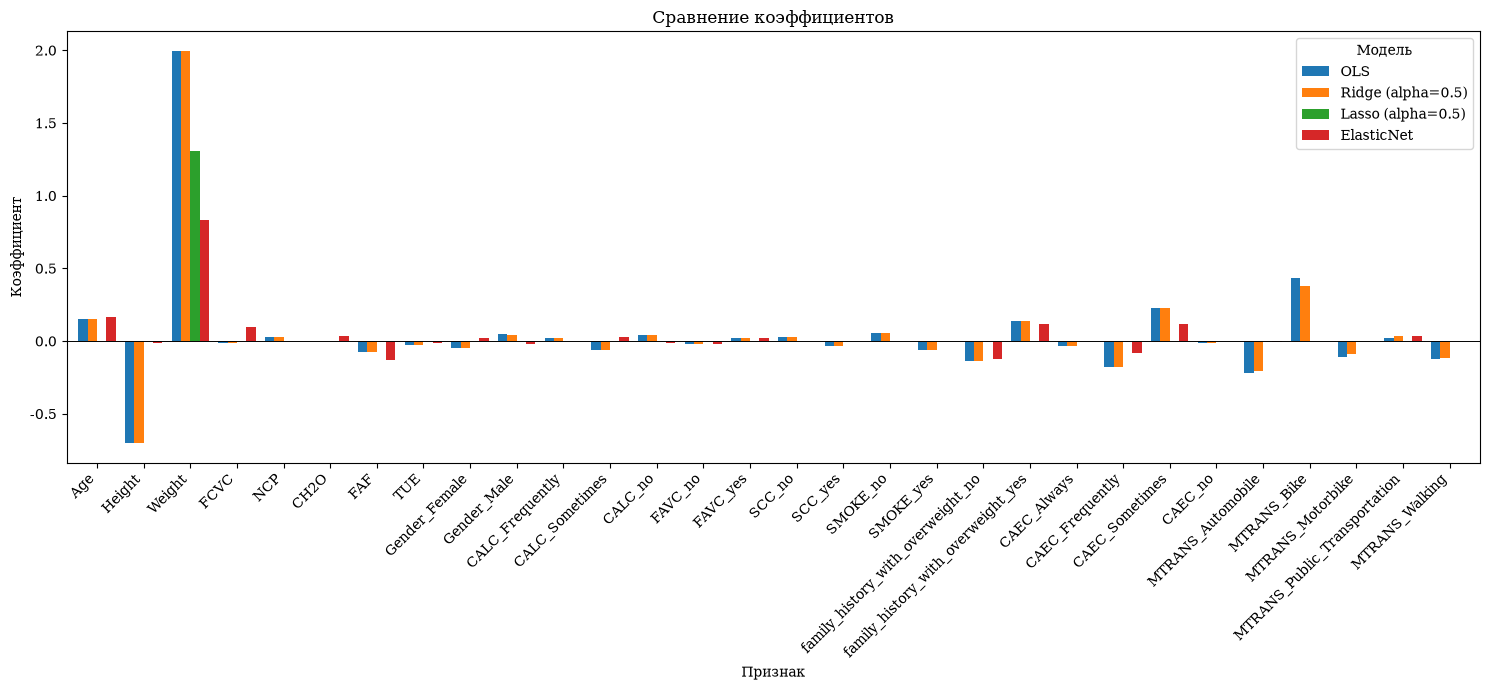

In [46]:
# Названия признаков после StandardScaler и OneHotEncoder
feature_names = preprocessor_reg.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]


# Коэффициенты обученных моделей
coefs = pd.DataFrame(
    {
        name: model.coef_
        for name, model in trained_models.items()
    },
    index=feature_names
)

models_to_plot = ['OLS', 'Ridge (alpha=0.5)', 'Lasso (alpha=0.5)', 'ElasticNet']

fig, ax = plt.subplots(figsize=(15, 7))
coefs[models_to_plot].plot.bar(ax=ax, width=0.8)

ax.set_title('Сравнение коэффициентов')
ax.set_xlabel('Признак')
ax.set_ylabel('Коэффициент')
ax.axhline(0, color='black', linewidth=0.7)
ax.legend(title='Модель')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

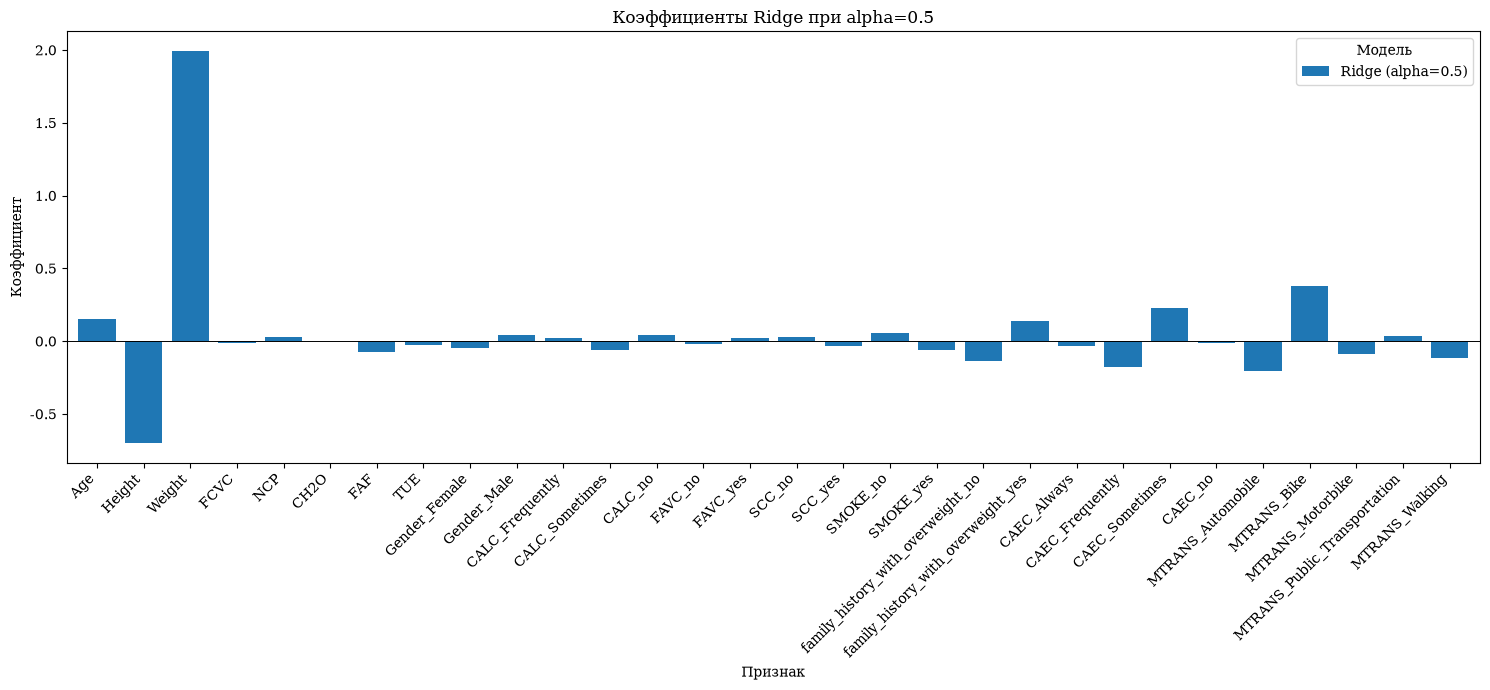

In [47]:
models_to_plot = ['Ridge (alpha=0.5)']
fig, ax = plt.subplots(figsize=(15, 7))
coefs[models_to_plot].plot.bar(ax=ax, width=0.8)

ax.set_title('Коэффициенты Ridge при alpha=0.5')
ax.set_xlabel('Признак')
ax.set_ylabel('Коэффициент')
ax.axhline(0, color='black', linewidth=0.7)
ax.legend(title='Модель')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

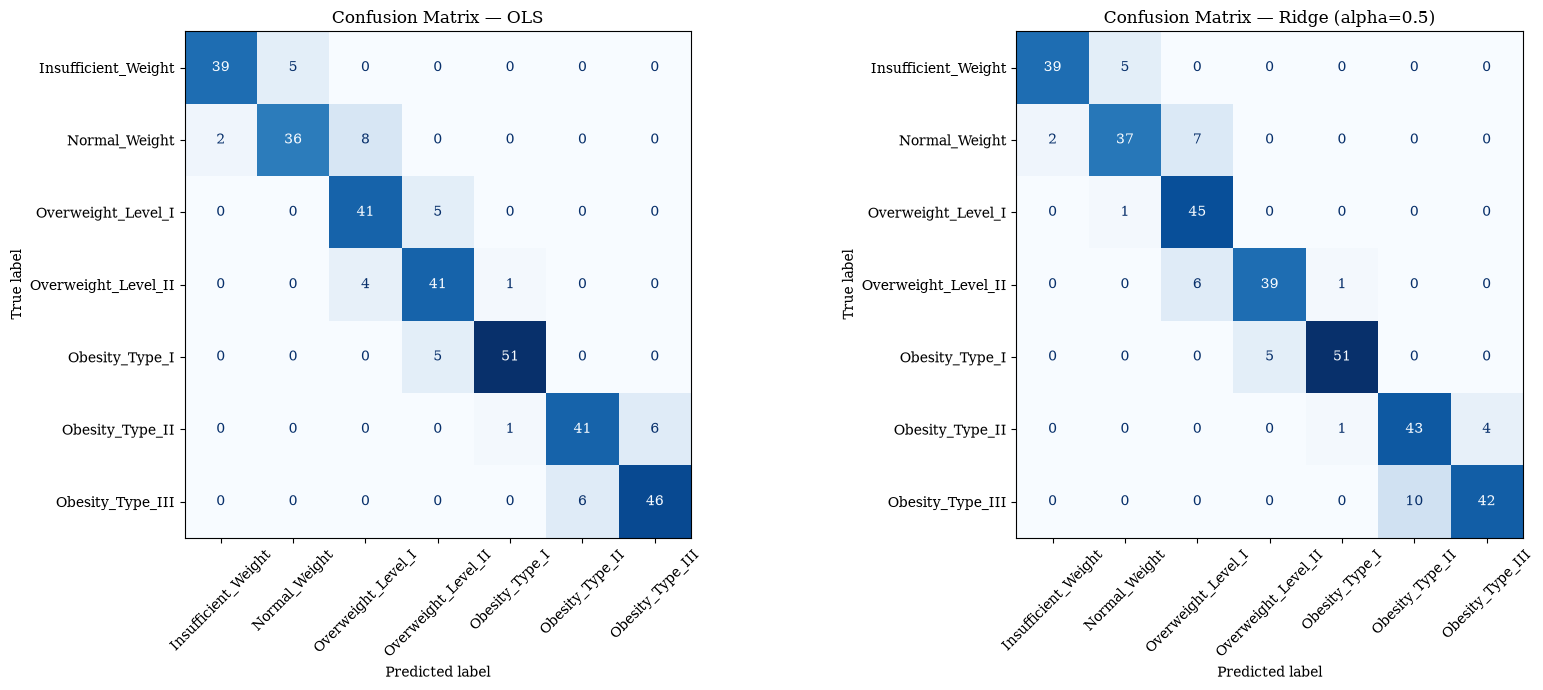

precision  recall  f1-score  support
Model             Class                                                    
OLS               Insufficient_Weight      0.951   0.886     0.918   44.000
                  Normal_Weight            0.878   0.783     0.828   46.000
                  Overweight_Level_I       0.774   0.891     0.828   46.000
                  Overweight_Level_II      0.804   0.891     0.845   46.000
                  Obesity_Type_I           0.962   0.911     0.936   56.000
                  Obesity_Type_II          0.872   0.854     0.863   48.000
                  Obesity_Type_III         0.885   0.885     0.885   52.000
                  accuracy                 0.873   0.873     0.873    0.873
                  macro avg                0.875   0.872     0.872  338.000
                  weighted avg             0.877   0.873     0.874  338.000
Ridge (alpha=0.5) Insufficient_Weight      0.951   0.886     0.918   44.000
                  Normal_Weight            0.860   0.804     0.831   46.000
                  Overweight_Level_I       0.776   0.978     0.865   46.000
                  Overweight_Level_II      0.886   0.848     0.867   46.000
                  Obesity_Type_I           0.962   0.911     0.936   56.000
                  Obesity_Type_II          0.811   0.896     0.851   48.000
                  Obesity_Type_III         0.913   0.808     0.857   52.000
                  accuracy                 0.876   0.876     0.876    0.876
                  macro avg                0.880   0.876     0.875  338.000
                  weighted avg             0.882   0.876     0.876  338.000

In [48]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)

models_to_evaluate = ['OLS', 'Ridge (alpha=0.5)']
reports = {}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))


for ax, name in zip(axes, models_to_evaluate):

    model = trained_models[name]
    thresholds = learned_thresholds[name]

    y_val_continuous = model.predict(X_val_reg_sc)
    y_val_class = np.digitize(y_val_continuous, bins=thresholds)

    ConfusionMatrixDisplay.from_predictions(
        y_val_reg,
        y_val_class,
        labels=np.arange(n_classes),
        display_labels=class_order,
        ax=ax,
        cmap='Blues',
        colorbar=False
    )

    ax.set_title(f'Confusion Matrix — {name}')
    ax.tick_params(axis='x', rotation=45)

    reports[name] = classification_report(
        y_val_reg,
        y_val_class,
        labels=np.arange(n_classes),
        target_names=class_order,
        output_dict=True,
        zero_division=0
    )


plt.tight_layout()
plt.show()

report_df = pd.concat(
    {
        name: pd.DataFrame(report).T
        for name, report in reports.items()
    },
    names=['Model', 'Class']
)

report_df.round(3)

## Многоклассовая классификация

### OvR и softmax

In [49]:
from sklearn.multiclass import OneVsRestClassifier

log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train_sc, y_train_cls)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_sc, y_train_cls)

y_pred_ovr = log_reg_ovr.predict(X_val_sc)
y_pred_mn = log_reg_mn.predict(X_val_sc)

pd.DataFrame({
    'OvR Accuracy': [accuracy_score(y_val_cls, y_pred_ovr)],
    'OvR F1 (macro)': [f1_score(y_val_cls, y_pred_ovr, average='macro')],
    'Softmax Accuracy': [accuracy_score(y_val_cls, y_pred_mn)],
    'Softmax F1 (macro)': [f1_score(y_val_cls, y_pred_mn, average='macro')],
}, index=['LogReg']).round(4)

,OvR Accuracy,OvR F1 (macro),Softmax Accuracy,Softmax F1 (macro)
LogReg,0.7219,0.7087,0.8521,0.8473


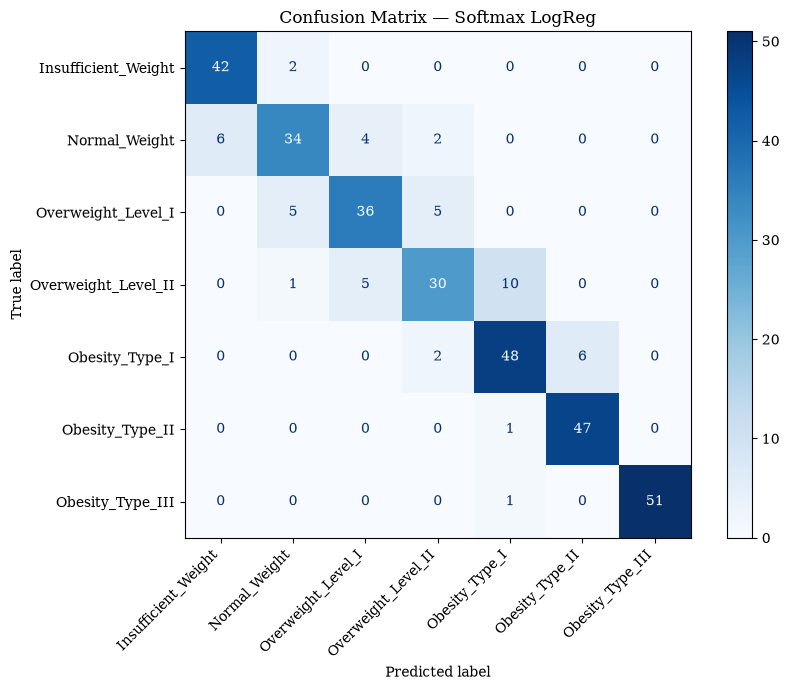

,precision,recall,f1-score,support
Insufficient_Weight,0.875,0.955,0.913,44.000
Normal_Weight,0.810,0.739,0.773,46.000
Overweight_Level_I,0.800,0.783,0.791,46.000
Overweight_Level_II,0.769,0.652,0.706,46.000
Obesity_Type_I,0.800,0.857,0.828,56.000
Obesity_Type_II,0.887,0.979,0.931,48.000
Obesity_Type_III,1.000,0.981,0.990,52.000
accuracy,0.852,0.852,0.852,0.852
macro avg,0.849,0.849,0.847,338.000
weighted avg,0.850,0.852,0.849,338.000


In [50]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_val_cls, y_pred_mn, display_labels=class_order, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Softmax LogReg')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
report = classification_report(y_val_cls, y_pred_mn, target_names=class_order, output_dict=True)
pd.DataFrame(report).T.round(3)

Переходим от линейных границ решений к деревьям и ансамблям: проверяем, дают ли нелинейные зависимости выигрыш на той же validation.

### Одно дерево и ансамбли

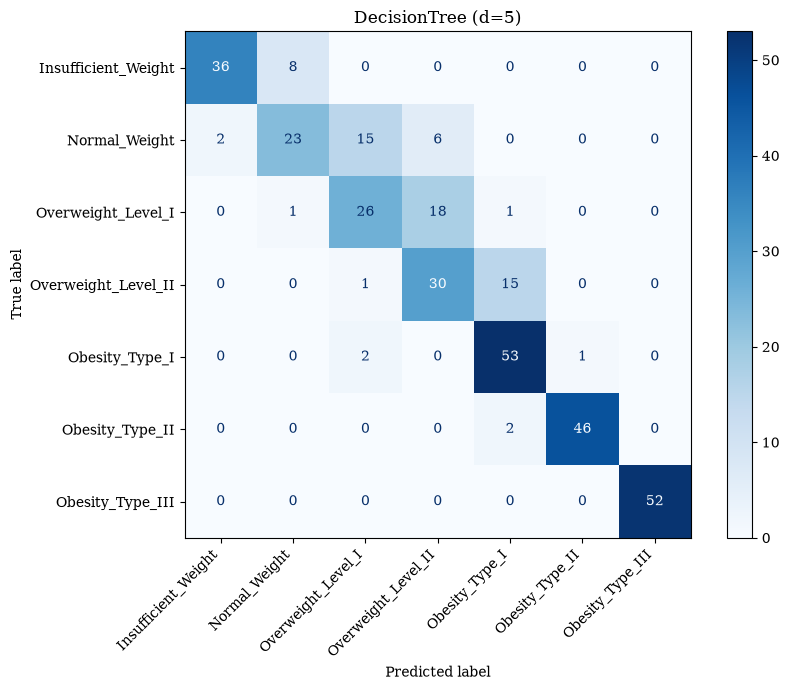

,precision,recall,f1-score,support
Insufficient_Weight,0.947,0.818,0.878,44.000
Normal_Weight,0.719,0.500,0.590,46.000
Overweight_Level_I,0.591,0.565,0.578,46.000
Overweight_Level_II,0.556,0.652,0.600,46.000
Obesity_Type_I,0.746,0.946,0.835,56.000
Obesity_Type_II,0.979,0.958,0.968,48.000
Obesity_Type_III,1.000,1.000,1.000,52.000
accuracy,0.787,0.787,0.787,0.787
macro avg,0.791,0.777,0.778,338.000
weighted avg,0.794,0.787,0.785,338.000


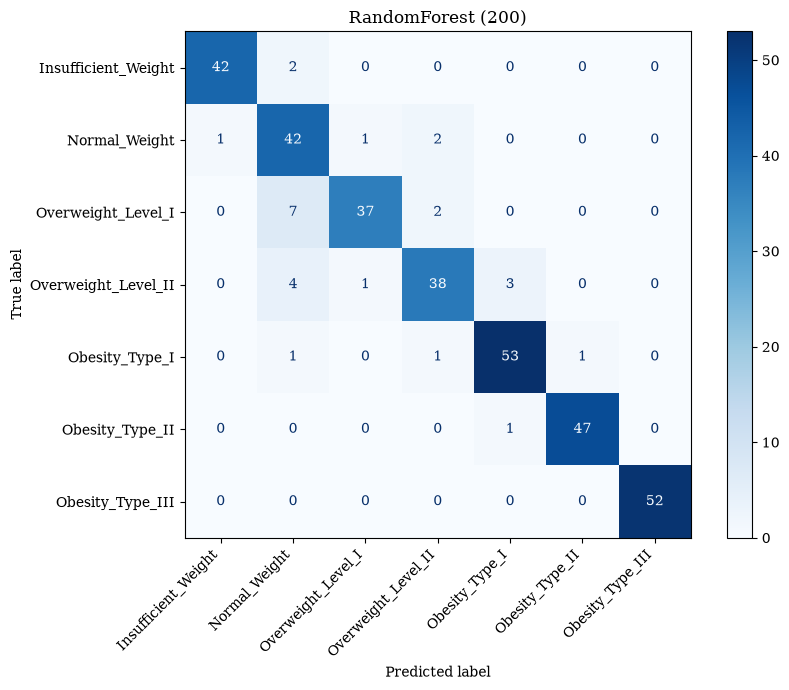

,precision,recall,f1-score,support
Insufficient_Weight,0.977,0.955,0.966,44.00
Normal_Weight,0.750,0.913,0.824,46.00
Overweight_Level_I,0.949,0.804,0.871,46.00
Overweight_Level_II,0.884,0.826,0.854,46.00
Obesity_Type_I,0.930,0.946,0.938,56.00
Obesity_Type_II,0.979,0.979,0.979,48.00
Obesity_Type_III,1.000,1.000,1.000,52.00
accuracy,0.920,0.920,0.920,0.92
macro avg,0.924,0.918,0.919,338.00
weighted avg,0.926,0.920,0.921,338.00


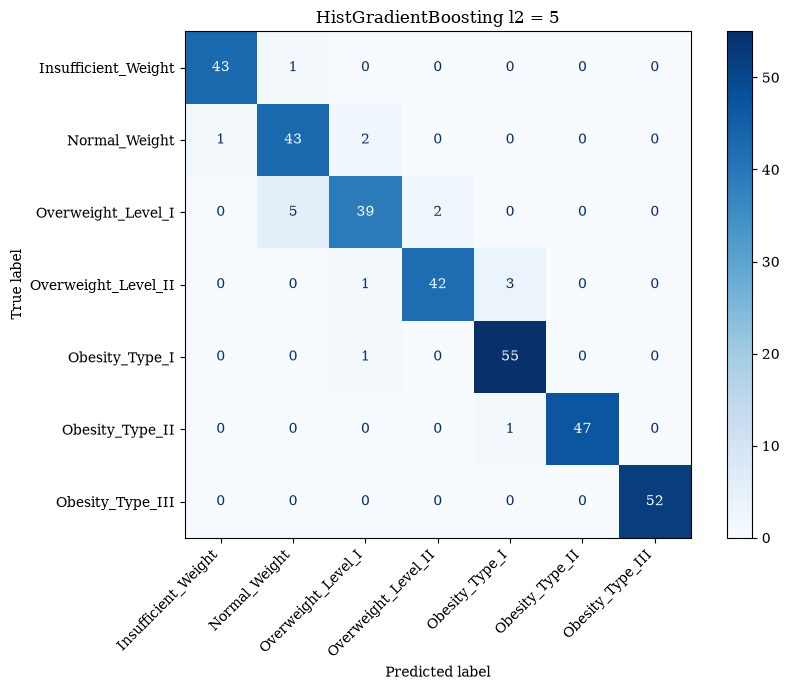

,precision,recall,f1-score,support
Insufficient_Weight,0.977,0.977,0.977,44.00
Normal_Weight,0.878,0.935,0.905,46.00
Overweight_Level_I,0.907,0.848,0.876,46.00
Overweight_Level_II,0.955,0.913,0.933,46.00
Obesity_Type_I,0.932,0.982,0.957,56.00
Obesity_Type_II,1.000,0.979,0.989,48.00
Obesity_Type_III,1.000,1.000,1.000,52.00
accuracy,0.950,0.950,0.950,0.95
macro avg,0.950,0.948,0.948,338.00
weighted avg,0.950,0.950,0.950,338.00


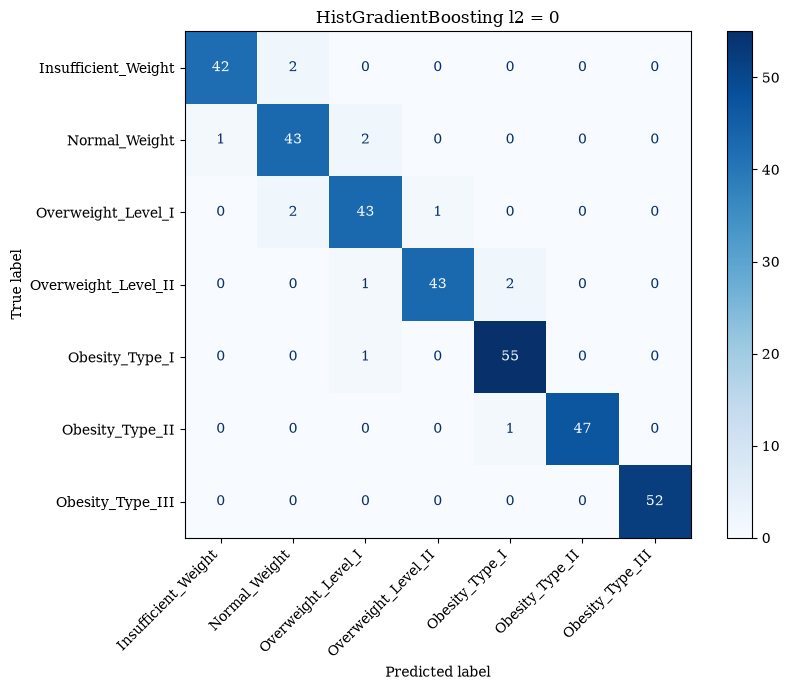

,precision,recall,f1-score,support
Insufficient_Weight,0.977,0.955,0.966,44.000
Normal_Weight,0.915,0.935,0.925,46.000
Overweight_Level_I,0.915,0.935,0.925,46.000
Overweight_Level_II,0.977,0.935,0.956,46.000
Obesity_Type_I,0.948,0.982,0.965,56.000
Obesity_Type_II,1.000,0.979,0.989,48.000
Obesity_Type_III,1.000,1.000,1.000,52.000
accuracy,0.962,0.962,0.962,0.962
macro avg,0.962,0.960,0.961,338.000
weighted avg,0.962,0.962,0.962,338.000


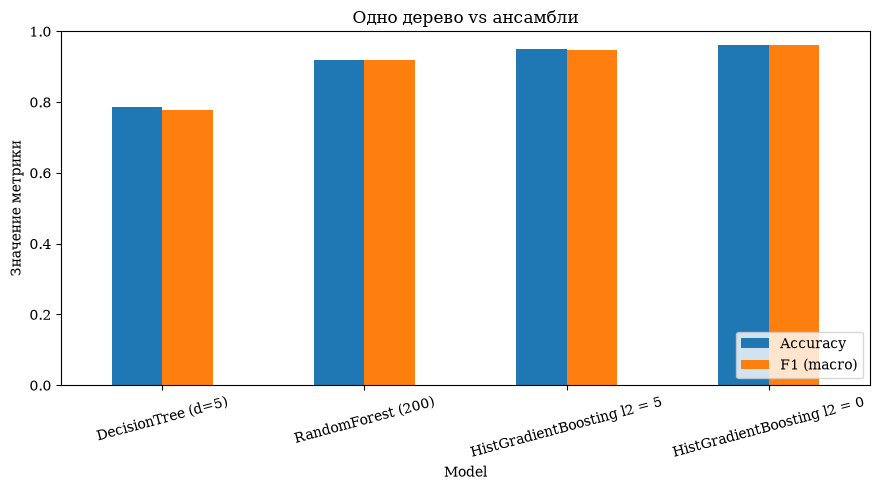

,Accuracy,F1 (macro)
Model,,
DecisionTree (d=5),0.7870,0.7784
RandomForest (200),0.9201,0.9187
HistGradientBoosting l2 = 5,0.9497,0.9483
HistGradientBoosting l2 = 0,0.9615,0.9607


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

ensemble_models = {
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest (200)': RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42, n_jobs=-1),
    'HistGradientBoosting l2 = 5': HistGradientBoostingClassifier(max_iter=300, random_state=42, l2_regularization=5.0),
    'HistGradientBoosting l2 = 0': HistGradientBoostingClassifier(max_iter=300, random_state=42, l2_regularization=0.0),
}
ens_res = []
for name, model in ensemble_models.items():
    model.fit(X_train_sc, y_train_cls)
    yp = model.predict(X_val_sc)
    ens_res.append({'Model': name, 'Accuracy': accuracy_score(y_val_cls, yp),
                    'F1 (macro)': f1_score(y_val_cls, yp, average='macro')})

    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay.from_predictions(y_val_cls, yp, display_labels=class_order, ax=ax, cmap='Blues')
    ax.set_title(name)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    report = classification_report(y_val_cls, yp, target_names=class_order, output_dict=True)
    display(pd.DataFrame(report).T.round(3))
                
    
df_ens = pd.DataFrame(ens_res).set_index('Model')

fig, ax = plt.subplots(figsize=(9, 5))
df_ens.plot.bar(ax=ax)
ax.set_ylim(0, 1.0); ax.set_ylabel('Значение метрики')
ax.set_title('Одно дерево vs ансамбли'); ax.tick_params(axis='x', rotation=15); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
df_ens.round(4)

### Оценим веса признаков модели


Best 10 feature : Index(['Weight', 'Age', 'FCVC', 'Height', 'NCP', 'CH2O', 'TUE', 'FAF',
       'Gender_Female', 'Gender_Male'],
      dtype='str')


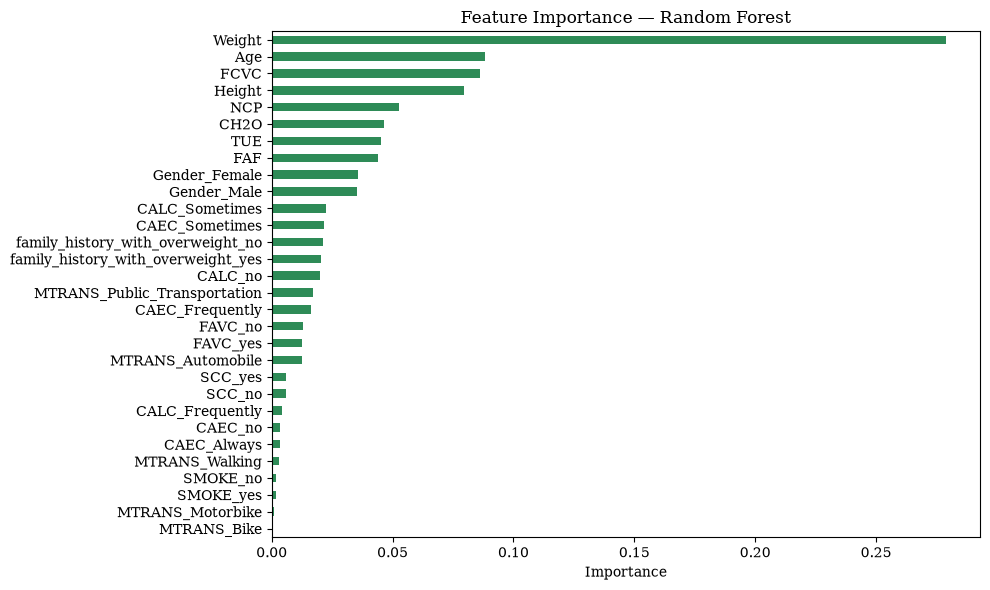

Best 10 feature : Index(['Weight', 'Height', 'Gender_Female', 'Age', 'FAVC_no', 'NCP', 'FAF',
       'CALC_Sometimes', 'family_history_with_overweight_no', 'CALC_no'],
      dtype='str')


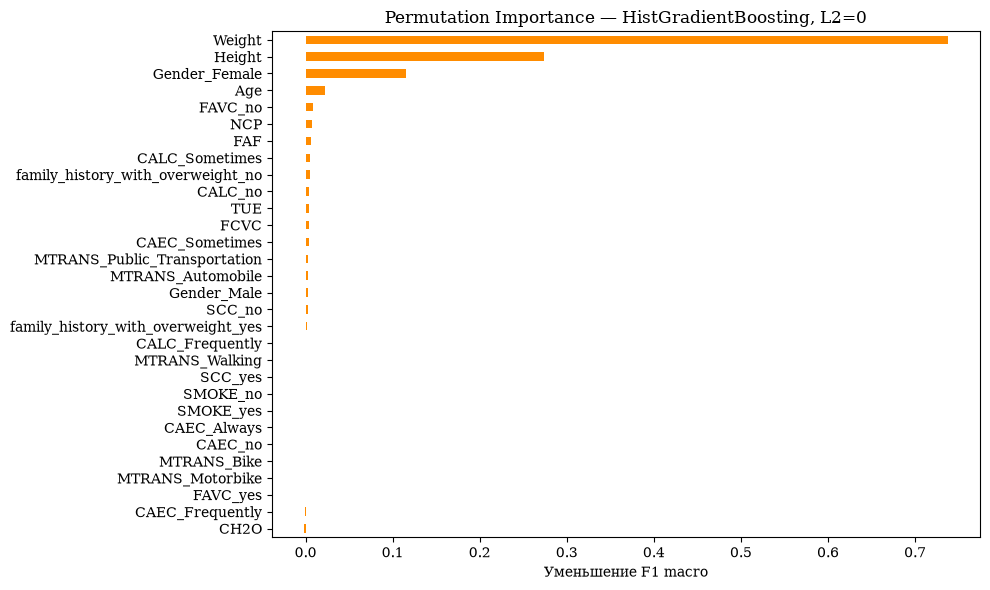

In [52]:
from sklearn.inspection import permutation_importance

rf_imp = pd.Series(ensemble_models['RandomForest (200)'].feature_importances_,
                   index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
rf_imp.plot.barh(ax=ax, color='seagreen')
ax.set_title('Feature Importance — Random Forest'); ax.set_xlabel('Importance')
print("Best 10 feature :", rf_imp.tail(10).index[::-1])
plt.tight_layout(); plt.show()




hgb_model = ensemble_models['HistGradientBoosting l2 = 0']
hgb_result = permutation_importance(
    hgb_model,
    X_val_sc,
    y_val_cls,
    scoring='f1_macro',
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

hgb_imp = pd.Series(hgb_result.importances_mean, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
hgb_imp.plot.barh(ax=ax, color='darkorange')

ax.set_title('Permutation Importance — HistGradientBoosting, L2=0')
ax.set_xlabel('Уменьшение F1 macro')
print("Best 10 feature :", hgb_imp.tail(10).index[::-1])
plt.tight_layout()
plt.show()

### Глубина и переобучение

,Train F1,Validation F1
depth,,
3,0.6066,0.5646
5,0.8445,0.7784
7,0.9439,0.8520
10,0.9985,0.9148
15,1.0000,0.9176
None,1.0000,0.9176


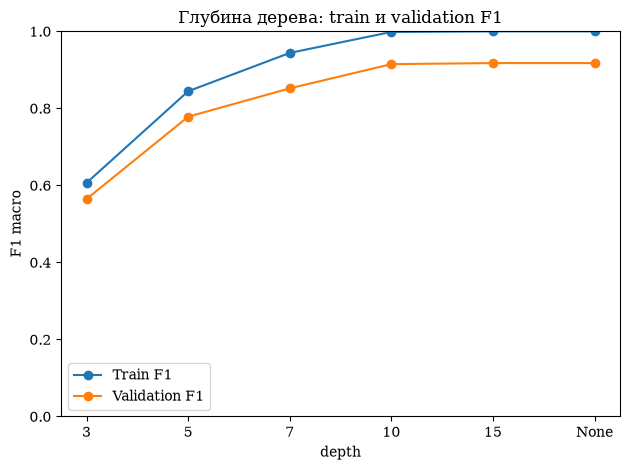

In [53]:
depth_rows = []
for depth in [3, 5, 7, 10, 15, None]:
    depth_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    depth_model.fit(X_train_sc, y_train_cls)
    depth_rows.append({
        'depth': str(depth),
        'Train F1': f1_score(y_train_cls, depth_model.predict(X_train_sc), average='macro'),
        'Validation F1': f1_score(y_val_cls, depth_model.predict(X_val_sc), average='macro')
    })
depth_df = pd.DataFrame(depth_rows).set_index('depth')
display(depth_df.round(4))
depth_df.plot(marker='o', ylim=(0, 1), title='Глубина дерева: train и validation F1')
plt.ylabel('F1 macro')
plt.tight_layout()
plt.show()

## Кросс-валидация и подбор гиперпараметров

### Ridge: подбор силы регуляризации

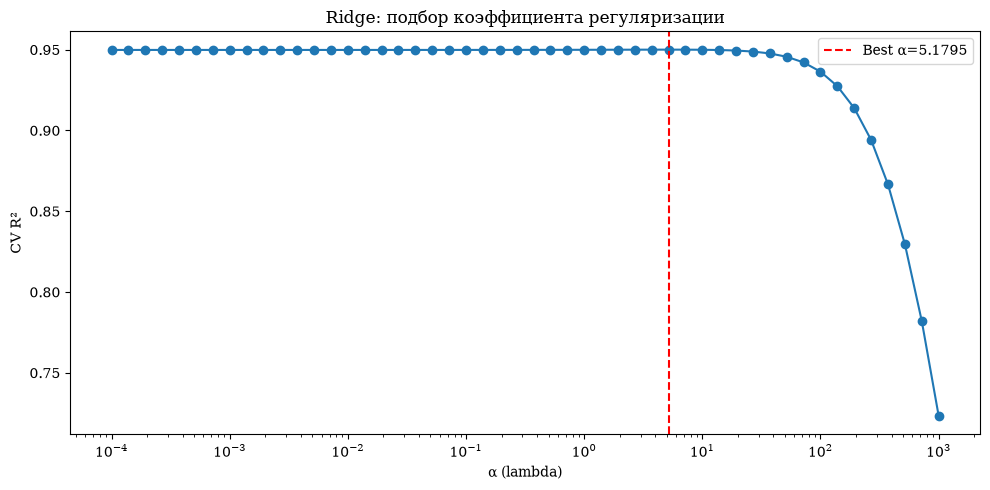

In [54]:
alphas = np.logspace(-4, 3, 50)
grid_ridge = GridSearchCV(
    Pipeline([('preprocessor', clone(preprocessor_reg)), ('model', Ridge())]), {'model__alpha': alphas}, cv=5, scoring='r2', n_jobs=-1
)
grid_ridge.fit(X_train_reg, y_train_reg)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas, grid_ridge.cv_results_['mean_test_score'], 'o-')
ax.axvline(grid_ridge.best_params_['model__alpha'], color='red', linestyle='--',
           label=f"Best α={grid_ridge.best_params_['model__alpha']:.4f}")
ax.set_xlabel('α (lambda)')
ax.set_ylabel('CV R²')
ax.set_title('Ridge: подбор коэффициента регуляризации')
ax.legend()
plt.tight_layout()
plt.show()

### HGB: случайный поиск

In [55]:
from scipy.stats import randint, loguniform

param_dist = {
    'learning_rate': loguniform(0.00001, 0.1),
    'max_iter': randint(100, 501),
    'max_depth': [None, 3, 5, 7, 10],
    'max_leaf_nodes': randint(2, 30),
    'min_samples_leaf': randint(1, 31)
}


rand_search = RandomizedSearchCV(estimator=Pipeline([('preprocessor', clone(preprocessor_cls)), ('model', HistGradientBoostingClassifier(random_state=52, l2_regularization=0))]),
    param_distributions={'model__' + key: value for key, value in param_dist.items()}, n_iter=50, cv=cv, scoring='f1_macro', random_state=52,
    n_jobs=-1, return_train_score=False)

rand_search.fit(X_train, y_train_cls)


print('Лучшие параметры:')
print(rand_search.best_params_)
print('Лучший CV F1 macro:', round(rand_search.best_score_, 4))

Лучшие параметры:
{'model__learning_rate': np.float64(0.07615392932555555), 'model__max_depth': 5, 'model__max_iter': 253, 'model__max_leaf_nodes': 14, 'model__min_samples_leaf': 10}
Лучший CV F1 macro: 0.972


In [56]:
search_val_f1 = f1_score(y_val_cls, rand_search.predict(X_val), average='macro')
baseline_val_f1 = df_ens.loc['HistGradientBoosting l2 = 0', 'F1 (macro)']
display(pd.DataFrame({'Validation F1': [baseline_val_f1, search_val_f1]},
                     index=['HGB исходный', 'HGB после CV-поиска']).round(4))

,Validation F1
HGB исходный,0.9607
HGB после CV-поиска,0.9575


## Отбор признаков

### SelectKBest + LogReg

In [57]:

k_values = [3, 5, 7, 10,  15, 20, 'all']
results_kbest = []

for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_sc, y_train_cls)
    X_val_sel = selector.transform(X_val_sc)
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_sel, y_train_cls)
    y_pred = model.predict(X_val_sel)
    
    n_features = X_train_sel.shape[1]
    results_kbest.append({
        'k': k,
        'n_features': n_features,
        'Accuracy': accuracy_score(y_val_cls, y_pred),
        'F1 (macro)': f1_score(y_val_cls, y_pred, average='macro'),
    })

df_kbest_logreg = pd.DataFrame(results_kbest)
df_kbest = df_kbest_logreg
df_kbest

,k,n_features,Accuracy,F1 (macro)
0,3,3,0.683432,0.679238
1,5,5,0.671598,0.664045
2,7,7,0.704142,0.688934
3,10,10,0.724852,0.710565
4,15,15,0.863905,0.860276
5,20,20,0.852071,0.847326
6,all,30,0.852071,0.847347


### SelectKBest + HGB

In [58]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

k_values = [3, 5, 7, 10, 15, 20, 'all']
results_kbest = []

for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_sc, y_train_cls)
    X_val_sel = selector.transform(X_val_sc)
    
    model = HistGradientBoostingClassifier(random_state=52, l2_regularization = 0)
    model.fit(X_train_sel, y_train_cls)
    y_pred = model.predict(X_val_sel)
    
    n_features = X_train_sel.shape[1]
    results_kbest.append({
        'k': k,
        'n_features': n_features,
        'Accuracy': accuracy_score(y_val_cls, y_pred),
        'F1 (macro)': f1_score(y_val_cls, y_pred, average='macro'),
    })

df_kbest_hgb = pd.DataFrame(results_kbest)
df_kbest = df_kbest_hgb
df_kbest

,k,n_features,Accuracy,F1 (macro)
0,3,3,0.751479,0.744701
1,5,5,0.751479,0.743444
2,7,7,0.807692,0.801369
3,10,10,0.899408,0.896790
4,15,15,0.955621,0.954576
5,20,20,0.955621,0.954775
6,all,30,0.958580,0.957621


## Выбор итогового кандидата и test

In [59]:
from sklearn.metrics import roc_auc_score

candidates = {}
def add_candidate(name, estimator, x_val, x_test, thresholds=None):
    pred = estimator.predict(x_val)
    if thresholds is not None:
        pred = np.digitize(pred, bins=thresholds)
    candidates[name] = {
        'model': estimator, 'test': x_test, 'thresholds': thresholds,
        'Validation F1 macro': f1_score(y_val_cls, pred, average='macro', zero_division=0)
    }

add_candidate('LogReg softmax', log_reg_mn, X_val_sc, X_test_sc)
add_candidate('LogReg OvR', log_reg_ovr, X_val_sc, X_test_sc)
for name, estimator in ensemble_models.items():
    add_candidate(name, estimator, X_val_sc, X_test_sc)
for name, estimator in trained_models.items():
    add_candidate(name + ' + пороги', estimator, X_val_reg_sc, X_test_reg_sc, learned_thresholds[name])
add_candidate('HGB после CV-поиска', rand_search.best_estimator_, X_val, X_test)
for label, table, estimator in [
    ('SelectKBest + LogReg', df_kbest_logreg, LogisticRegression(max_iter=1000, random_state=42)),
    ('SelectKBest + HGB', df_kbest_hgb, HistGradientBoostingClassifier(random_state=52, l2_regularization=0))
]:
    best_k = table.loc[table['F1 (macro)'].idxmax(), 'k']
    best_k = best_k if best_k == 'all' else int(best_k)
    selected_model = Pipeline([('selector', SelectKBest(f_classif, k=best_k)), ('model', estimator)])
    selected_model.fit(X_train_sc, y_train_cls)
    add_candidate(f'{label}, k={best_k}', selected_model, X_val_sc, X_test_sc)

comparison_df = pd.DataFrame({name: {'Validation F1 macro': item['Validation F1 macro']} for name, item in candidates.items()}).T
display(comparison_df.sort_values('Validation F1 macro', ascending=False).round(4))
winner_name = max(candidates, key=lambda name: candidates[name]['Validation F1 macro'])
winner = candidates[winner_name]
test_pred = winner['model'].predict(winner['test'])
if winner['thresholds'] is not None:
    test_pred = np.digitize(test_pred, bins=winner['thresholds'])
test_metrics = {
    'Accuracy': accuracy_score(y_test_cls, test_pred),
    'F1 macro': f1_score(y_test_cls, test_pred, average='macro', zero_division=0),
    'MAE class': mean_absolute_error(y_test_cls, test_pred)
}
if winner['thresholds'] is None and hasattr(winner['model'], 'predict_proba'):
    test_metrics['ROC-AUC OvR macro'] = roc_auc_score(y_test_cls, winner['model'].predict_proba(winner['test']), multi_class='ovr', average='macro')
display(pd.DataFrame([test_metrics], index=[winner_name]).round(4))
print(classification_report(y_test_cls, test_pred, labels=np.arange(n_classes), target_names=class_order, zero_division=0))

,Validation F1 macro
HistGradientBoosting l2 = 0,0.9607
"SelectKBest + HGB, k=all",0.9576
HGB после CV-поиска,0.9575
HistGradientBoosting l2 = 5,0.9483
RandomForest (200),0.9187
Ridge (alpha=0.5) + пороги,0.8751
OLS + пороги,0.8718
Ridge (alpha=10) + пороги,0.8689
"SelectKBest + LogReg, k=15",0.8603
LogReg softmax,0.8473


,Accuracy,F1 macro,MAE class,ROC-AUC OvR macro
HistGradientBoosting l2 = 0,0.9716,0.9713,0.0284,0.998


                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.95      0.95      0.95        58
 Overweight_Level_I       0.95      0.93      0.94        58
Overweight_Level_II       0.95      0.98      0.97        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65

           accuracy                           0.97       423
          macro avg       0.97      0.97      0.97       423
       weighted avg       0.97      0.97      0.97       423



## Итоги

1. Деревья будут лучше решать задачу многоклассовой классификации — гипотеза подтвердилась. Ансамбли деревьев показали лучшие результаты: F1 macro составила 0,952 для Random Forest и 0,981 для HistGradientBoosting, тогда как у многоклассовой логистической регрессии — 0,890.
2. Из-за небольшого количества данных и большого числа классов деревья будут переобучаться при глубине больше 5 — гипотеза не подтверждена.
3.  Weight сильно коррелирует с FAF, SMOKE, SCC, NCP, FCVC и FAVC — гипотеза не подтверждена.
4.  Комбинация Height и Weight вносит основной вклад в предсказание — гипотеза подтвердилась, так как все модели дают им наибольшие веса.
5.  Регрессия с порогами будет лучше обычной многоклассовой классификации благодаря упорядоченности классов — гипотеза не подтверждена.
    В исходном запуске тестовый F1 macro составил около 0,861 для OLS с порогами и 0,865 для Ridge с порогами, против 0,890 у многоклассовой логистической регрессии. Упорядоченность классов делает такой подход осмысленным, но не гарантирует превосходство.

Отдельно отмечу, что модель основанная на градиентном бустинге идеально предстказывает именно последние стадии ожирения, что для данной задачи является более хорошим критерием, чем определять разницу между стадиями в пределах нормы.